# Notebook 06 — Fixed-γ Summary, Longitudinal Statistics, and Manuscript Panels

This notebook converts the per-session γ-sweep outputs into **paper-style summary analyses**.

## Goals
1. Load the γ-sweep results produced by Notebook 05.
2. Derive a **fixed γ** for early and late sessions from the distribution of per-session optimal γ values.
3. Quantify how much decoding improves relative to threshold crossings (TC, γ=0).
4. Test whether later sessions benefit more than earlier sessions.
5. Generate publication-style summary figures and statistics.
6. Export clean tables for manuscript writing.

## Inputs
This notebook expects output from Notebook 05. It can use either:
- a **full** results file containing `acc_curve` and `frac_removed_curve`, or
- a **summary** results file containing only session-level metrics.

If full curves are available, the notebook will also generate normalized mean γ-curves.

In [1]:
import os
import ast
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

np.random.seed(42)
print("Imports OK")

Imports OK


In [2]:
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    13,
    "axes.linewidth":    1.2,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "xtick.major.size":  6,
    "ytick.major.size":  6,
    "xtick.minor.size":  3,
    "ytick.minor.size":  3,
    "legend.fontsize":   11,
    "legend.frameon":    True,
    "legend.edgecolor":  "0.4",
    "grid.linestyle":    ":",
    "grid.linewidth":    0.7,
    "grid.alpha":        0.85,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.6)
    for sp in ax.spines.values():
        sp.set_linewidth(1.2)
    ax.tick_params(which="both", direction="in", top=True, right=True)

## Configuration

Set the early/late cutoff and the expected input paths here.

- `EARLY_LATE_CUTOFF = 180` keeps this notebook aligned with the split used in the previous Monkey-N notebooks.
- If you want the split to more closely mimic the original NAS paper, you can change it manually.

In [3]:
WORK_ROOT = Path("/kaggle/working")
WORK_ROOT1= Path("/kaggle/input/datasets/katakuricharlotte/nas-style-adaptive-sweep-decoder-results")

FIG_DIR   = WORK_ROOT / "figures_nb06"
TAB_DIR   = WORK_ROOT / "tables_nb06"
META_DIR  = WORK_ROOT / "meta_nb06"

for d in [FIG_DIR, TAB_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EARLY_LATE_CUTOFF = 180
GAMMA_GRID_DEFAULT = np.round(np.concatenate([
    np.arange(0.00, 0.20, 0.02),
    np.arange(0.20, 0.50, 0.05),
    np.arange(0.50, 0.96, 0.05),
]), 3)

CANDIDATE_INPUTS = [
    WORK_ROOT1 / "tables_gamma" / "gamma_sweep_results_full.csv",
    WORK_ROOT1 / "tables_gamma" / "gamma_sweep_results_full.jsonl",
    WORK_ROOT1 / "tables_gamma" / "gamma_sweep_results.csv",
]

print("Candidate input files:")
for p in CANDIDATE_INPUTS:
    print(" -", p)

Candidate input files:
 - /kaggle/input/datasets/katakuricharlotte/nas-style-adaptive-sweep-decoder-results/tables_gamma/gamma_sweep_results_full.csv
 - /kaggle/input/datasets/katakuricharlotte/nas-style-adaptive-sweep-decoder-results/tables_gamma/gamma_sweep_results_full.jsonl
 - /kaggle/input/datasets/katakuricharlotte/nas-style-adaptive-sweep-decoder-results/tables_gamma/gamma_sweep_results.csv


## Load Notebook 05 results

This loader supports:
- CSV with scalar columns only,
- CSV with list-valued columns stored as strings,
- JSONL with one session per line.

In [4]:
def _parse_maybe_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                return ast.literal_eval(s)
            except Exception:
                return x
    return x

def load_results_from_path(path_obj):
    suffix = path_obj.suffix.lower()
    if suffix == ".csv":
        df = pd.read_csv(path_obj)
        for col in ["acc_curve", "frac_removed_curve", "unit_rates"]:
            if col in df.columns:
                df[col] = df[col].apply(_parse_maybe_list)
        return df
    elif suffix == ".jsonl":
        rows = []
        with open(path_obj, "r") as f:
            for line in f:
                if line.strip():
                    rows.append(json.loads(line))
        return pd.DataFrame(rows)
    else:
        raise ValueError(f"Unsupported file type: {path_obj}")

input_path = None
for p in CANDIDATE_INPUTS:
    if p.exists():
        input_path = p
        break

assert input_path is not None, (
    "No Notebook 05 results file found. "
    "Place one of the expected files in /kaggle/working/tables_gamma/."
)

gamma_df = load_results_from_path(input_path)
print("Loaded:", input_path)
print("Shape :", gamma_df.shape)
print("Columns:")
print(list(gamma_df.columns))

Loaded: /kaggle/input/datasets/katakuricharlotte/nas-style-adaptive-sweep-decoder-results/tables_gamma/gamma_sweep_results_full.csv
Shape : (156, 17)
Columns:
['file_name', 'status', 'session_index', 'days_since_first_session', 'early_late', 'n_units', 'n_classes', 'label_col_used', 'tc_accuracy', 'max_accuracy', 'delta_acc_raw', 'optimal_gamma', 'acc_curve', 'frac_removed_curve', 'unit_rates', 'pct_low_quality', 'pct_high_quality']


In [5]:
assert len(gamma_df) > 0, "Input results table is empty."

# Keep only valid sessions if a status column is present
if "status" in gamma_df.columns:
    gamma_df = gamma_df[gamma_df["status"] == "ok"].copy()

# Ensure core columns exist
required_core = ["file_name", "tc_accuracy", "max_accuracy", "delta_acc_raw", "optimal_gamma"]
missing = [c for c in required_core if c not in gamma_df.columns]
assert len(missing) == 0, f"Missing required columns: {missing}"

# Harmonize day column
assert "days_since_first_session" in gamma_df.columns, \
    "days_since_first_session is required for longitudinal analyses."

gamma_df["days_since_first_session"] = pd.to_numeric(
    gamma_df["days_since_first_session"], errors="coerce"
)

# Rebuild early/late if needed
gamma_df["early_late"] = np.where(
    gamma_df["days_since_first_session"] <= EARLY_LATE_CUTOFF,
    "early", "late"
)

# Safe numeric coercion
for col in ["tc_accuracy", "max_accuracy", "delta_acc_raw", "optimal_gamma", "n_units", "n_classes"]:
    if col in gamma_df.columns:
        gamma_df[col] = pd.to_numeric(gamma_df[col], errors="coerce")

FULL_CURVES_AVAILABLE = (
    "acc_curve" in gamma_df.columns and
    gamma_df["acc_curve"].apply(lambda x: isinstance(x, list)).any()
)

print(f"Valid sessions retained   : {len(gamma_df)}")
print(f"Full curves available     : {FULL_CURVES_AVAILABLE}")
print(f"Early sessions (≤{EARLY_LATE_CUTOFF} d): {(gamma_df['early_late']=='early').sum()}")
print(f"Late sessions  (>{EARLY_LATE_CUTOFF} d): {(gamma_df['early_late']=='late').sum()}")

display(gamma_df.head(5))

Valid sessions retained   : 156
Full curves available     : True
Early sessions (≤180 d): 12
Late sessions  (>180 d): 144


,file_name,status,session_index,days_since_first_session,early_late,n_units,n_classes,label_col_used,tc_accuracy,max_accuracy,delta_acc_raw,optimal_gamma,acc_curve,frac_removed_curve,unit_rates,pct_low_quality,pct_high_quality
0,sub-Monkey-N_ses-20200127_ecephys.nwb,ok,1,0,early,96,7,index_target_position,0.586667,0.586667,0.000000,0.02,"[0.5866666666666667, 0.5866666666666667, 0.578...","[0.0, 0.0, 0.04166666666666663, 0.322916666666...","[3.3187501430511475, 2.039583444595337, 12.649...",84.375000,1.041667
1,sub-Monkey-N_ses-20200130_ecephys.nwb,ok,2,3,early,94,7,index_target_position,0.544000,0.557333,1.333333,0.02,"[0.544, 0.544, 0.5466666666666666, 0.549333333...","[0.0, 0.0, 0.10416666666666663, 0.364583333333...","[9.160416603088379, 2.6854166984558105, 35.645...",73.958333,5.208333
2,sub-Monkey-N_ses-20200204_ecephys.nwb,ok,3,8,early,96,7,index_target_position,0.506667,0.528000,2.133333,0.02,"[0.5066666666666667, 0.5066666666666667, 0.509...","[0.0, 0.0, 0.14583333333333337, 0.375, 0.47916...","[5.729100704193115, 1.8814815282821655, 24.571...",79.166667,5.208333
3,sub-Monkey-N_ses-20200205_ecephys.nwb,ok,4,9,early,94,7,index_target_position,0.304000,0.373333,6.933333,0.35,"[0.304, 0.30133333333333334, 0.304, 0.30133333...","[0.0, 0.01041666666666663, 0.20833333333333337...","[16.15416717529297, 4.9395833015441895, 36.75,...",75.000000,5.208333
4,sub-Monkey-N_ses-20200206_ecephys.nwb,ok,5,10,early,95,7,index_target_position,0.573333,0.581333,0.800000,0.02,"[0.5733333333333334, 0.576, 0.5733333333333334...","[0.0, 0.01041666666666663, 0.02083333333333337...","[9.10130500793457, 4.533999443054199, 23.13405...",68.750000,6.250000


## Derive fixed γ values for early and late cohorts

We estimate one cohort-level γ for early sessions and one for late sessions by:
1. taking the median of the per-session `optimal_gamma`,
2. snapping that value to the nearest tested γ on the grid.

This mimics the idea of a fixed threshold used across sessions rather than tuning γ separately every day.

In [6]:
def infer_gamma_grid(df, fallback=GAMMA_GRID_DEFAULT):
    if "acc_curve" in df.columns:
        lengths = df["acc_curve"].apply(lambda x: len(x) if isinstance(x, list) else np.nan).dropna()
        if len(lengths) and int(lengths.mode().iloc[0]) == len(fallback):
            return fallback
    return fallback

def snap_to_grid(x, grid):
    if pd.isna(x):
        return np.nan
    return float(grid[np.argmin(np.abs(grid - x))])

GAMMA_GRID = infer_gamma_grid(gamma_df)

fixed_gamma_rows = []
for grp in ["early", "late"]:
    sub = gamma_df[(gamma_df["early_late"] == grp) & (~gamma_df["optimal_gamma"].isna())]
    med = np.nan if len(sub) == 0 else float(np.nanmedian(sub["optimal_gamma"]))
    snapped = snap_to_grid(med, GAMMA_GRID) if not np.isnan(med) else np.nan
    fixed_gamma_rows.append({
        "group": grp,
        "n_sessions_with_opt_gamma": len(sub),
        "median_optimal_gamma": med,
        "fixed_gamma_snapped": snapped,
    })

fixed_gamma_df = pd.DataFrame(fixed_gamma_rows)
fixed_gamma_df.to_csv(TAB_DIR / "fixed_gamma_by_group.csv", index=False)
display(fixed_gamma_df.style.format({
    "median_optimal_gamma": "{:.3f}",
    "fixed_gamma_snapped": "{:.3f}",
}))

,group,n_sessions_with_opt_gamma,median_optimal_gamma,fixed_gamma_snapped
0,early,12,0.020,0.020
1,late,144,0.020,0.020


## Figure 1 — Distribution of per-session optimal γ

This figure shows how `optimal_gamma` differs between early and late sessions,
with the cohort-level fixed γ overlaid as a dashed line.

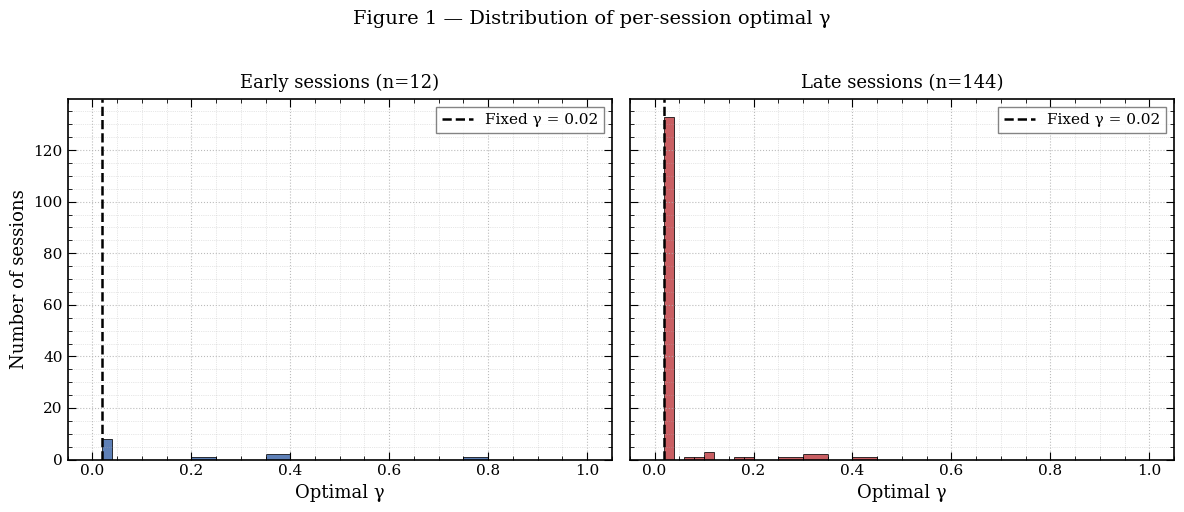

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, grp, col in zip(axes, ["early", "late"], ["#4C72B0", "#C44E52"]):
    sub = gamma_df[(gamma_df["early_late"] == grp) & (~gamma_df["optimal_gamma"].isna())]
    ax.hist(sub["optimal_gamma"], bins=np.append(GAMMA_GRID, GAMMA_GRID[-1] + 0.05),
            color=col, edgecolor="black", linewidth=0.6, alpha=0.9)

    fg = fixed_gamma_df.loc[fixed_gamma_df["group"] == grp, "fixed_gamma_snapped"].iloc[0]
    if not np.isnan(fg):
        ax.axvline(fg, color="black", lw=1.8, ls="--", label=f"Fixed γ = {fg:.2f}")

    ax.set_xlabel("Optimal γ")
    ax.set_title(f"{grp.capitalize()} sessions (n={len(sub)})", pad=8)
    paper_axes(ax)
    ax.legend(loc="upper right", frameon=True, fancybox=False)

axes[0].set_ylabel("Number of sessions")
fig.suptitle("Figure 1 — Distribution of per-session optimal γ", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_optimal_gamma_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig01_optimal_gamma_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Session-level fixed-γ evaluation

If full sweep curves are available, we compute each session's decoding accuracy
at the fixed γ for its cohort and compare it with:
- threshold crossings (TC, γ=0),
- the session's own best γ result.

If full curves are not available, this section will be skipped safely.

In [8]:
def pick_curve_value(acc_curve, gamma_grid, gamma_value):
    if not isinstance(acc_curve, list):
        return np.nan
    if len(acc_curve) != len(gamma_grid):
        return np.nan
    gi = int(np.argmin(np.abs(gamma_grid - gamma_value)))
    try:
        return float(acc_curve[gi])
    except Exception:
        return np.nan

if FULL_CURVES_AVAILABLE:
    gamma_df_full = gamma_df.copy()

    group_to_fixed = dict(zip(fixed_gamma_df["group"], fixed_gamma_df["fixed_gamma_snapped"]))
    gamma_df_full["fixed_gamma_group"] = gamma_df_full["early_late"].map(group_to_fixed)
    gamma_df_full["fixed_gamma_accuracy"] = gamma_df_full.apply(
        lambda r: pick_curve_value(r["acc_curve"], GAMMA_GRID, r["fixed_gamma_group"]), axis=1
    )
    gamma_df_full["fixed_delta_acc"] = (gamma_df_full["fixed_gamma_accuracy"] - gamma_df_full["tc_accuracy"]) * 100
    gamma_df_full["loss_vs_optimal_pp"] = (gamma_df_full["max_accuracy"] - gamma_df_full["fixed_gamma_accuracy"]) * 100

    gamma_df_full.to_csv(TAB_DIR / "gamma_results_with_fixed_gamma.csv", index=False)

    display_cols = [
        "file_name", "early_late", "optimal_gamma", "fixed_gamma_group",
        "tc_accuracy", "fixed_gamma_accuracy", "max_accuracy",
        "fixed_delta_acc", "loss_vs_optimal_pp"
    ]
    display(
        gamma_df_full[display_cols].head(10).style.format({
            "optimal_gamma": "{:.2f}",
            "fixed_gamma_group": "{:.2f}",
            "tc_accuracy": "{:.3f}",
            "fixed_gamma_accuracy": "{:.3f}",
            "max_accuracy": "{:.3f}",
            "fixed_delta_acc": "{:+.2f} pp",
            "loss_vs_optimal_pp": "{:+.2f} pp",
        })
    )
else:
    print("Skipping fixed-γ session evaluation because acc_curve is not available.")

,file_name,early_late,optimal_gamma,fixed_gamma_group,tc_accuracy,fixed_gamma_accuracy,max_accuracy,fixed_delta_acc,loss_vs_optimal_pp
0,sub-Monkey-N_ses-20200127_ecephys.nwb,early,0.02,0.02,0.587,nan,0.587,+nan pp,+nan pp
1,sub-Monkey-N_ses-20200130_ecephys.nwb,early,0.02,0.02,0.544,0.544,0.557,+0.00 pp,+1.33 pp
2,sub-Monkey-N_ses-20200204_ecephys.nwb,early,0.02,0.02,0.507,0.507,0.528,+0.00 pp,+2.13 pp
3,sub-Monkey-N_ses-20200205_ecephys.nwb,early,0.35,0.02,0.304,nan,0.373,+nan pp,+nan pp
4,sub-Monkey-N_ses-20200206_ecephys.nwb,early,0.02,0.02,0.573,nan,0.581,+nan pp,+nan pp
5,sub-Monkey-N_ses-20200211_ecephys.nwb,early,0.35,0.02,0.360,0.360,0.408,+0.00 pp,+4.80 pp
6,sub-Monkey-N_ses-20200222_ecephys.nwb,early,0.02,0.02,0.603,nan,0.608,+nan pp,+nan pp
7,sub-Monkey-N_ses-20200224_ecephys.nwb,early,0.02,0.02,0.499,nan,0.496,+nan pp,+nan pp
8,sub-Monkey-N_ses-20200225_ecephys.nwb,early,0.20,0.02,0.531,nan,0.565,+nan pp,+nan pp
9,sub-Monkey-N_ses-20200626_ecephys.nwb,early,0.75,0.02,0.397,nan,0.429,+nan pp,+nan pp


## Figure 2 — Δ accuracy vs. days since first session

This is the main longitudinal summary using the **best per-session γ** result.

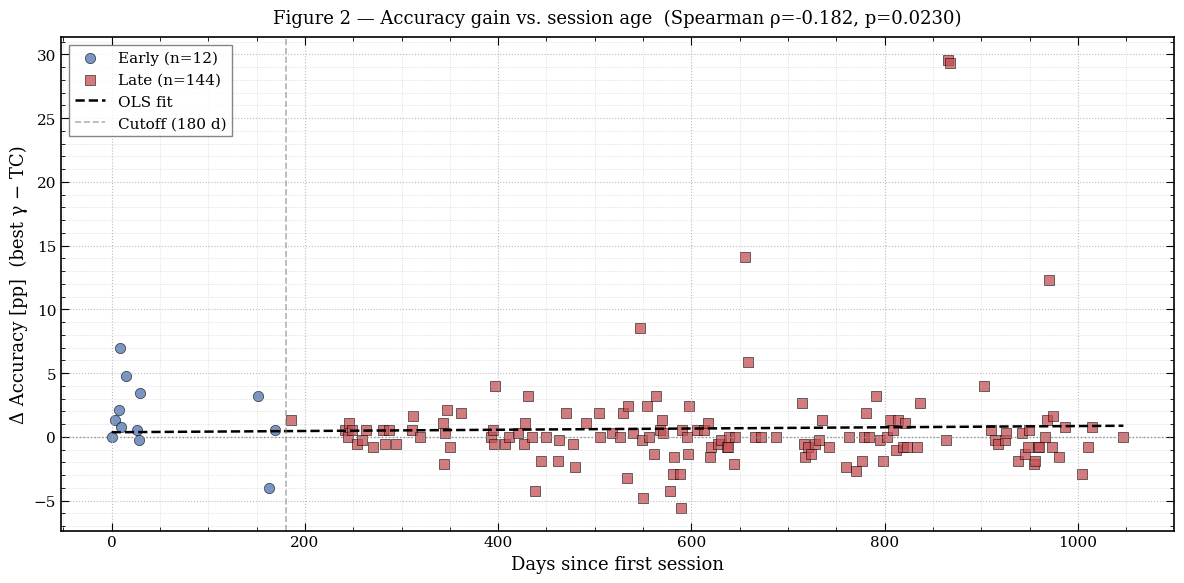

Spearman ρ = -0.1819
p-value    = 0.023047


In [9]:
valid = gamma_df[["days_since_first_session", "delta_acc_raw", "early_late"]].dropna()
rho, pval = stats.spearmanr(valid["days_since_first_session"], valid["delta_acc_raw"])

fig, ax = plt.subplots(figsize=(12, 6))

for grp, col, marker in [("early", "#4C72B0", "o"), ("late", "#C44E52", "s")]:
    sub = valid[valid["early_late"] == grp]
    ax.scatter(
        sub["days_since_first_session"], sub["delta_acc_raw"],
        color=col, marker=marker, s=55, alpha=0.75,
        edgecolor="black", linewidth=0.5, label=f"{grp.capitalize()} (n={len(sub)})"
    )

if len(valid) >= 3:
    m, b = np.polyfit(valid["days_since_first_session"], valid["delta_acc_raw"], 1)
    x_line = np.linspace(valid["days_since_first_session"].min(), valid["days_since_first_session"].max(), 200)
    ax.plot(x_line, m * x_line + b, color="black", lw=1.8, ls="--", label="OLS fit")

ax.axhline(0, color="gray", lw=1.0, ls=":", alpha=0.8)
ax.axvline(EARLY_LATE_CUTOFF, color="gray", lw=1.2, ls="--", alpha=0.6,
           label=f"Cutoff ({EARLY_LATE_CUTOFF} d)")

ax.set_xlabel("Days since first session")
ax.set_ylabel("Δ Accuracy [pp]  (best γ − TC)")
ax.set_title(
    f"Figure 2 — Accuracy gain vs. session age  (Spearman ρ={rho:.3f}, p={pval:.4f})",
    pad=10
)
paper_axes(ax)
ax.legend(loc="upper left", frameon=True, fancybox=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_delta_acc_vs_days.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig02_delta_acc_vs_days.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"Spearman ρ = {rho:.4f}")
print(f"p-value    = {pval:.6f}")

## Figure 3 — Early vs. late Δ accuracy distributions

This is the cohort comparison for the per-session best γ benefit.

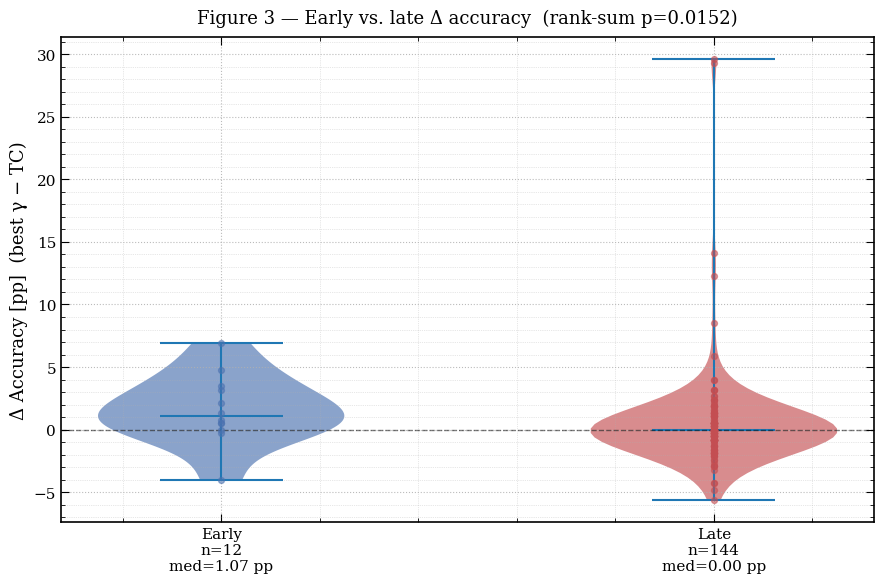

Rank-sum statistic = -2.4275
Rank-sum p-value   = 0.015203


In [10]:
early_delta = gamma_df.loc[gamma_df["early_late"] == "early", "delta_acc_raw"].dropna().values
late_delta  = gamma_df.loc[gamma_df["early_late"] == "late",  "delta_acc_raw"].dropna().values

stat_rs, pval_rs = stats.ranksums(late_delta, early_delta)

fig, ax = plt.subplots(figsize=(9, 6))
parts = ax.violinplot([early_delta, late_delta], positions=[0, 1],
                      showmedians=True, showextrema=True)

for pc, col in zip(parts["bodies"], ["#4C72B0", "#C44E52"]):
    pc.set_facecolor(col)
    pc.set_alpha(0.65)

ax.scatter(np.zeros_like(early_delta), early_delta, color="#4C72B0", s=18, alpha=0.55, zorder=3)
ax.scatter(np.ones_like(late_delta),  late_delta,  color="#C44E52", s=18, alpha=0.55, zorder=3)

ax.axhline(0, color="black", lw=1.0, ls="--", alpha=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels([
    f"Early\nn={len(early_delta)}\nmed={np.median(early_delta):.2f} pp",
    f"Late\nn={len(late_delta)}\nmed={np.median(late_delta):.2f} pp",
])
ax.set_ylabel("Δ Accuracy [pp]  (best γ − TC)")
ax.set_title(f"Figure 3 — Early vs. late Δ accuracy  (rank-sum p={pval_rs:.4f})", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_early_late_delta_acc_violin.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig03_early_late_delta_acc_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"Rank-sum statistic = {stat_rs:.4f}")
print(f"Rank-sum p-value   = {pval_rs:.6f}")

## Figure 4 — TC vs. best-γ accuracy

This is the paired, within-session summary.

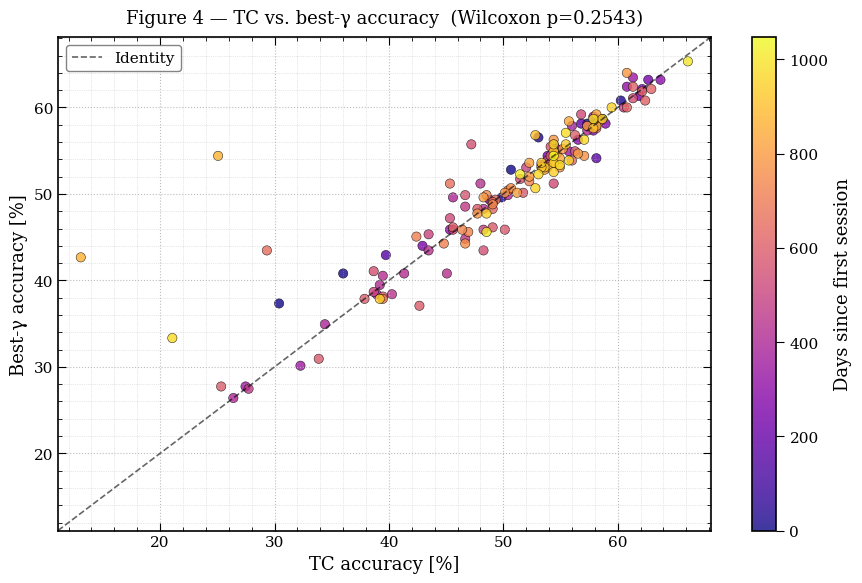

Wilcoxon signed-rank statistic = 4820.0000
Wilcoxon signed-rank p-value   = 0.254272
Sessions improved: 68/156


In [11]:
pair_df = gamma_df[["tc_accuracy", "max_accuracy", "days_since_first_session"]].dropna().copy()
stat_w, pval_w = stats.wilcoxon(pair_df["max_accuracy"], pair_df["tc_accuracy"], alternative="greater")

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    pair_df["tc_accuracy"] * 100,
    pair_df["max_accuracy"] * 100,
    c=pair_df["days_since_first_session"],
    cmap="plasma",
    s=45,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4
)

lims = [
    min(pair_df["tc_accuracy"].min(), pair_df["max_accuracy"].min()) * 100 - 2,
    max(pair_df["tc_accuracy"].max(), pair_df["max_accuracy"].max()) * 100 + 2,
]
ax.plot(lims, lims, "k--", lw=1.2, alpha=0.6, label="Identity")
ax.set_xlim(lims)
ax.set_ylim(lims)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Days since first session")

ax.set_xlabel("TC accuracy [%]")
ax.set_ylabel("Best-γ accuracy [%]")
ax.set_title(f"Figure 4 — TC vs. best-γ accuracy  (Wilcoxon p={pval_w:.4f})", pad=10)
paper_axes(ax)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_tc_vs_best_gamma.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig04_tc_vs_best_gamma.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"Wilcoxon signed-rank statistic = {stat_w:.4f}")
print(f"Wilcoxon signed-rank p-value   = {pval_w:.6f}")
print(f"Sessions improved: {(pair_df['max_accuracy'] > pair_df['tc_accuracy']).sum()}/{len(pair_df)}")

## Figure 5 — Fixed-γ evaluation by cohort

This panel uses the cohort-level fixed γ value instead of each session's own optimal γ.
It is only generated when full `acc_curve` data are available.

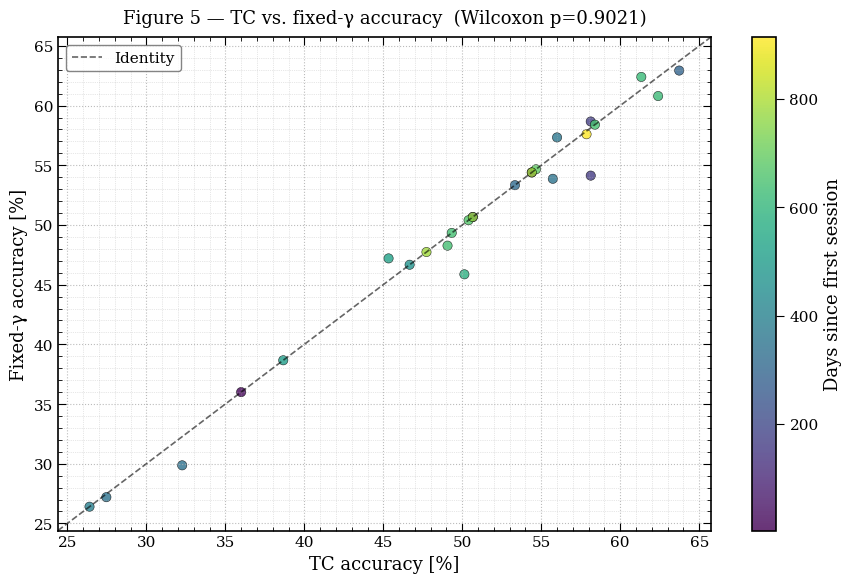

Wilcoxon signed-rank statistic = 43.0000
Wilcoxon signed-rank p-value   = 0.902095


In [12]:
if FULL_CURVES_AVAILABLE:
    fg_df = gamma_df_full.dropna(subset=["fixed_gamma_accuracy", "tc_accuracy"]).copy()

    stat_fix, pval_fix = stats.wilcoxon(
        fg_df["fixed_gamma_accuracy"], fg_df["tc_accuracy"], alternative="greater"
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    sc = ax.scatter(
        fg_df["tc_accuracy"] * 100,
        fg_df["fixed_gamma_accuracy"] * 100,
        c=fg_df["days_since_first_session"],
        cmap="viridis",
        s=45,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4
    )

    lims = [
        min(fg_df["tc_accuracy"].min(), fg_df["fixed_gamma_accuracy"].min()) * 100 - 2,
        max(fg_df["tc_accuracy"].max(), fg_df["fixed_gamma_accuracy"].max()) * 100 + 2,
    ]
    ax.plot(lims, lims, "k--", lw=1.2, alpha=0.6, label="Identity")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Days since first session")

    ax.set_xlabel("TC accuracy [%]")
    ax.set_ylabel("Fixed-γ accuracy [%]")
    ax.set_title(f"Figure 5 — TC vs. fixed-γ accuracy  (Wilcoxon p={pval_fix:.4f})", pad=10)
    paper_axes(ax)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig05_tc_vs_fixed_gamma.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "fig05_tc_vs_fixed_gamma.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Wilcoxon signed-rank statistic = {stat_fix:.4f}")
    print(f"Wilcoxon signed-rank p-value   = {pval_fix:.6f}")
else:
    print("Skipping Figure 5 because full acc_curve data are not available.")

## Figure 6 — Mean normalized γ-curves by cohort

For each session we normalize the accuracy curve by its TC accuracy:
`normalized_accuracy(γ) = accuracy(γ) / accuracy(TC)`.

This is only generated when full curves are available.

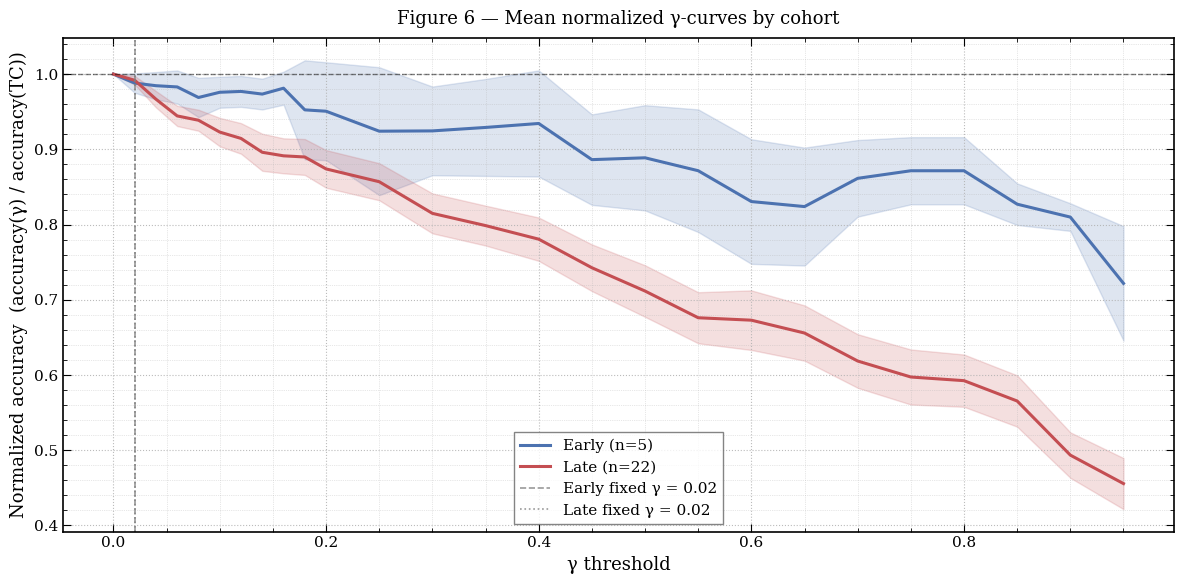

In [13]:
if FULL_CURVES_AVAILABLE:
    def normalize_curve(acc_curve):
        if not isinstance(acc_curve, list) or len(acc_curve) != len(GAMMA_GRID):
            return None
        arr = np.asarray(acc_curve, dtype=float)
        tc = arr[0]
        if np.isnan(tc) or tc <= 0:
            return None
        return arr / tc

    gamma_df_full["norm_curve"] = gamma_df_full["acc_curve"].apply(normalize_curve)

    early_curves = np.array([
        x for x in gamma_df_full.loc[gamma_df_full["early_late"] == "early", "norm_curve"]
        if isinstance(x, np.ndarray)
    ])
    late_curves = np.array([
        x for x in gamma_df_full.loc[gamma_df_full["early_late"] == "late", "norm_curve"]
        if isinstance(x, np.ndarray)
    ])

    fig, ax = plt.subplots(figsize=(12, 6))

    for curves, col, lbl in [
        (early_curves, "#4C72B0", "Early"),
        (late_curves,  "#C44E52", "Late"),
    ]:
        if len(curves) == 0:
            continue
        mean_c = np.nanmean(curves, axis=0)
        sem_c  = np.nanstd(curves, axis=0) / np.sqrt(np.sum(~np.isnan(curves), axis=0).clip(1))
        ax.plot(GAMMA_GRID, mean_c, color=col, lw=2.2, label=f"{lbl} (n={len(curves)})")
        ax.fill_between(GAMMA_GRID, mean_c - sem_c, mean_c + sem_c, color=col, alpha=0.18)

    # fixed group gammas
    for grp, ls in [("early", "--"), ("late", ":")]:
        fg = fixed_gamma_df.loc[fixed_gamma_df["group"] == grp, "fixed_gamma_snapped"].iloc[0]
        if not np.isnan(fg):
            ax.axvline(fg, color="gray", lw=1.2, ls=ls, alpha=0.8,
                       label=f"{grp.capitalize()} fixed γ = {fg:.2f}")

    ax.axhline(1.0, color="black", lw=1.0, ls="--", alpha=0.5)
    ax.set_xlabel("γ threshold")
    ax.set_ylabel("Normalized accuracy  (accuracy(γ) / accuracy(TC))")
    ax.set_title("Figure 6 — Mean normalized γ-curves by cohort", pad=10)
    paper_axes(ax)
    ax.legend(loc="best", frameon=True, fancybox=False)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig06_normalized_gamma_curves.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "fig06_normalized_gamma_curves.pdf", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Skipping Figure 6 because full acc_curve data are not available.")

## Figure 7 — Quality fractions vs. days since first session

These panels are only produced if `pct_low_quality` and `pct_high_quality` are present
in the Notebook 05 results table.

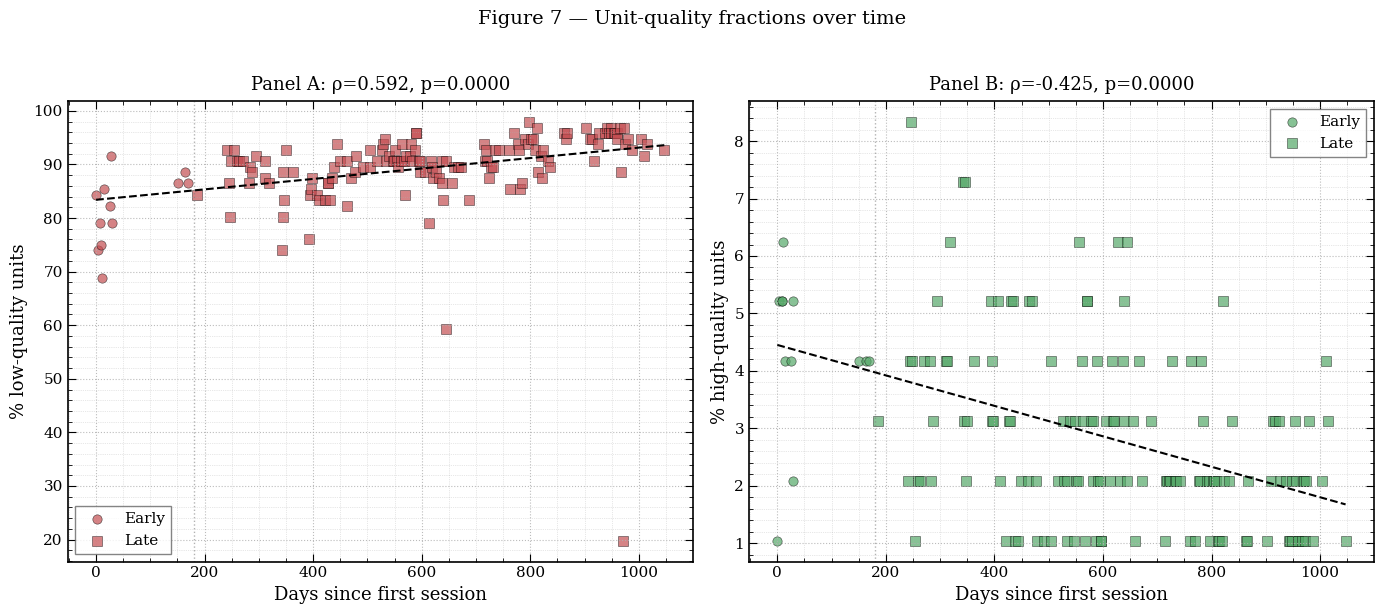

In [14]:
have_quality = ("pct_low_quality" in gamma_df.columns) and ("pct_high_quality" in gamma_df.columns)

if have_quality:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, col_y, ylabel, color, panel in [
        (axes[0], "pct_low_quality",  "% low-quality units",  "#C44E52", "A"),
        (axes[1], "pct_high_quality", "% high-quality units", "#55A868", "B"),
    ]:
        sub = gamma_df[["days_since_first_session", "early_late", col_y]].dropna()

        for grp, marker in [("early", "o"), ("late", "s")]:
            sg = sub[sub["early_late"] == grp]
            ax.scatter(
                sg["days_since_first_session"], sg[col_y],
                color=color, marker=marker, s=45, alpha=0.7,
                edgecolor="black", linewidth=0.4, label=grp.capitalize()
            )

        if len(sub) >= 3:
            rho_q, p_q = stats.spearmanr(sub["days_since_first_session"], sub[col_y])
            m_q, b_q = np.polyfit(sub["days_since_first_session"], sub[col_y], 1)
            x_q = np.linspace(sub["days_since_first_session"].min(), sub["days_since_first_session"].max(), 200)
            ax.plot(x_q, m_q * x_q + b_q, color="black", lw=1.5, ls="--")
            ttl = f"Panel {panel}: ρ={rho_q:.3f}, p={p_q:.4f}"
        else:
            ttl = f"Panel {panel}"

        ax.axvline(EARLY_LATE_CUTOFF, color="gray", lw=1.0, ls=":", alpha=0.6)
        ax.set_xlabel("Days since first session")
        ax.set_ylabel(ylabel)
        ax.set_title(ttl, pad=8)
        paper_axes(ax)
        ax.legend(loc="best", frameon=True, fancybox=False)

    fig.suptitle("Figure 7 — Unit-quality fractions over time", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig07_quality_fractions_vs_days.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "fig07_quality_fractions_vs_days.pdf", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Skipping Figure 7 because quality-fraction columns are not available.")

## Statistical summary table

In [15]:
stats_rows = []

# best-γ vs days
valid_best = gamma_df[["days_since_first_session", "delta_acc_raw"]].dropna()
if len(valid_best) >= 3:
    rho_best, p_best = stats.spearmanr(valid_best["days_since_first_session"], valid_best["delta_acc_raw"])
    stats_rows.append({
        "analysis": "Spearman — best Δacc vs. days",
        "statistic": rho_best,
        "p_value": p_best,
    })

# optimal γ vs days
valid_opt = gamma_df[["days_since_first_session", "optimal_gamma"]].dropna()
if len(valid_opt) >= 3:
    rho_opt, p_opt = stats.spearmanr(valid_opt["days_since_first_session"], valid_opt["optimal_gamma"])
    stats_rows.append({
        "analysis": "Spearman — optimal γ vs. days",
        "statistic": rho_opt,
        "p_value": p_opt,
    })

# early vs late
if len(early_delta) > 0 and len(late_delta) > 0:
    stat_rs2, p_rs2 = stats.ranksums(late_delta, early_delta)
    stats_rows.append({
        "analysis": "Rank-sum — late vs. early best Δacc",
        "statistic": stat_rs2,
        "p_value": p_rs2,
    })

# within-session best vs tc
if len(pair_df) > 0:
    stat_w2, p_w2 = stats.wilcoxon(pair_df["max_accuracy"], pair_df["tc_accuracy"], alternative="greater")
    stats_rows.append({
        "analysis": "Wilcoxon — best γ > TC",
        "statistic": stat_w2,
        "p_value": p_w2,
    })

# fixed gamma vs tc
if FULL_CURVES_AVAILABLE:
    fg_df2 = gamma_df_full.dropna(subset=["fixed_gamma_accuracy", "tc_accuracy"]).copy()
    if len(fg_df2) > 0:
        stat_fix2, p_fix2 = stats.wilcoxon(
            fg_df2["fixed_gamma_accuracy"], fg_df2["tc_accuracy"], alternative="greater"
        )
        stats_rows.append({
            "analysis": "Wilcoxon — fixed γ > TC",
            "statistic": stat_fix2,
            "p_value": p_fix2,
        })

stats_table = pd.DataFrame(stats_rows)
stats_table["significant_alpha_0_05"] = stats_table["p_value"].apply(lambda p: "✓" if p < 0.05 else "✗")
stats_table.to_csv(TAB_DIR / "nb06_statistical_summary.csv", index=False)

display(stats_table.style.format({
    "statistic": "{:.4f}",
    "p_value": "{:.6f}",
}))

,analysis,statistic,p_value,significant_alpha_0_05
0,Spearman — best Δacc vs. days,-0.1819,0.023047,✓
1,Spearman — optimal γ vs. days,-0.0881,0.274106,✗
2,Rank-sum — late vs. early best Δacc,-2.4275,0.015203,✓
3,Wilcoxon — best γ > TC,4820.0000,0.254272,✗
4,Wilcoxon — fixed γ > TC,43.0000,0.902095,✗


## Manuscript-ready summary table

In [16]:
summary_rows = []

for grp in ["early", "late", "all"]:
    sub = gamma_df if grp == "all" else gamma_df[gamma_df["early_late"] == grp]

    row = {
        "group": grp,
        "n_sessions": len(sub),
        "median_tc_accuracy_pct": np.nanmedian(sub["tc_accuracy"]) * 100,
        "median_best_accuracy_pct": np.nanmedian(sub["max_accuracy"]) * 100,
        "median_delta_acc_pp": np.nanmedian(sub["delta_acc_raw"]),
        "median_optimal_gamma": np.nanmedian(sub["optimal_gamma"]),
        "mean_optimal_gamma": np.nanmean(sub["optimal_gamma"]),
    }

    if FULL_CURVES_AVAILABLE:
        fg = fixed_gamma_df.loc[fixed_gamma_df["group"] == grp, "fixed_gamma_snapped"].iloc[0] if grp in ["early", "late"] else np.nan
        row["fixed_gamma_group"] = fg

    summary_rows.append(row)

manuscript_table = pd.DataFrame(summary_rows)
manuscript_table.to_csv(TAB_DIR / "nb06_manuscript_summary_table.csv", index=False)

display(manuscript_table.style.format({
    "median_tc_accuracy_pct": "{:.2f}",
    "median_best_accuracy_pct": "{:.2f}",
    "median_delta_acc_pp": "{:+.2f}",
    "median_optimal_gamma": "{:.3f}",
    "mean_optimal_gamma": "{:.3f}",
    "fixed_gamma_group": "{:.3f}",
}))

,group,n_sessions,median_tc_accuracy_pct,median_best_accuracy_pct,median_delta_acc_pp,median_optimal_gamma,mean_optimal_gamma,fixed_gamma_group
0,early,12,53.73,54.93,+1.07,0.020,0.151,0.020
1,late,144,52.80,52.93,+0.00,0.020,0.033,0.020
2,all,156,52.93,53.07,+0.00,0.020,0.042,nan


## Save notebook metadata

In [17]:
meta = {
    "input_path": str(input_path),
    "n_sessions": int(len(gamma_df)),
    "full_curves_available": bool(FULL_CURVES_AVAILABLE),
    "early_late_cutoff_days": int(EARLY_LATE_CUTOFF),
    "gamma_grid": GAMMA_GRID.tolist(),
}

with open(META_DIR / "nb06_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))

{
  "input_path": "/kaggle/input/datasets/katakuricharlotte/nas-style-adaptive-sweep-decoder-results/tables_gamma/gamma_sweep_results_full.csv",
  "n_sessions": 156,
  "full_curves_available": true,
  "early_late_cutoff_days": 180,
  "gamma_grid": [
    0.0,
    0.02,
    0.04,
    0.06,
    0.08,
    0.1,
    0.12,
    0.14,
    0.16,
    0.18,
    0.2,
    0.25,
    0.3,
    0.35,
    0.4,
    0.45,
    0.5,
    0.55,
    0.6,
    0.65,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9,
    0.95
  ]
}


## Output summary

In [18]:
figs = sorted([p.name for p in FIG_DIR.glob("*")])
tabs = sorted([p.name for p in TAB_DIR.glob("*")])
mets = sorted([p.name for p in META_DIR.glob("*")])

print("Figures:")
for x in figs:
    print(" -", x)

print("\nTables:")
for x in tabs:
    print(" -", x)

print("\nMetadata:")
for x in mets:
    print(" -", x)

print("\nNotebook 06 completed.")

Figures:
 - fig01_optimal_gamma_distribution.pdf
 - fig01_optimal_gamma_distribution.png
 - fig02_delta_acc_vs_days.pdf
 - fig02_delta_acc_vs_days.png
 - fig03_early_late_delta_acc_violin.pdf
 - fig03_early_late_delta_acc_violin.png
 - fig04_tc_vs_best_gamma.pdf
 - fig04_tc_vs_best_gamma.png
 - fig05_tc_vs_fixed_gamma.pdf
 - fig05_tc_vs_fixed_gamma.png
 - fig06_normalized_gamma_curves.pdf
 - fig06_normalized_gamma_curves.png
 - fig07_quality_fractions_vs_days.pdf
 - fig07_quality_fractions_vs_days.png

Tables:
 - fixed_gamma_by_group.csv
 - gamma_results_with_fixed_gamma.csv
 - nb06_manuscript_summary_table.csv
 - nb06_statistical_summary.csv

Metadata:
 - nb06_metadata.json

Notebook 06 completed.
